### Import Library

In [19]:
import xgboost as xgb
from catboost import CatBoostRegressor
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [20]:
df = pd.read_csv("realtor-data.zip.csv")

print(f"Size of dataset: {df.shape[0]}")
print(f"Features in dataset: {df.columns.tolist()}")

df.head()

Size of dataset: 2226382
Features in dataset: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


### Preprocessing

Because the data is too big, it will take a lot of time to run, therefore, in order to reduce run time, only 10k random data points will be considered

In [21]:
df = df.sample(n=10000, random_state=42)

Describe data

In [22]:
df.describe(include='all') # include = 'all' to include categorical data

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
count,9976.000000,10000,9.991000e+03,7824.000000,7707.000000,8480.000000,9.959000e+03,9998,10000,10000.000000,7386.000000,6683
unique,NaN,3,NaN,NaN,NaN,NaN,NaN,3991,54,NaN,NaN,2341
top,NaN,for_sale,NaN,NaN,NaN,NaN,NaN,Houston,Florida,NaN,NaN,2022-04-15
freq,NaN,6234,NaN,NaN,NaN,NaN,NaN,112,1123,NaN,NaN,79
mean,52805.763232,NaN,5.316304e+05,3.237219,2.466459,27.548237,1.012074e+06,NaN,NaN,52665.229400,2000.000271,NaN
std,30484.202393,NaN,1.398862e+06,1.250935,1.248102,1165.408487,5.798694e+05,NaN,NaN,29166.621229,1250.228351,NaN
min,8.000000,NaN,1.000000e+00,1.000000,1.000000,0.000000,1.660000e+02,NaN,NaN,603.000000,192.000000,NaN
25%,24196.000000,NaN,1.649000e+05,3.000000,2.000000,0.160000,5.225690e+05,NaN,NaN,29670.000000,1286.000000,NaN
50%,52826.500000,NaN,3.250000e+05,3.000000,2.000000,0.270000,1.008828e+06,NaN,NaN,49417.000000,1728.000000,NaN
75%,79199.000000,NaN,5.490000e+05,4.000000,3.000000,1.000000,1.512217e+06,NaN,NaN,78410.250000,2379.000000,NaN


Checking for missing value:

In [23]:
df.isnull().sum()

brokered_by         24
status               0
price                9
bed               2176
bath              2293
acre_lot          1520
street              41
city                 2
state                0
zip_code             0
house_size        2614
prev_sold_date    3317
dtype: int64

Filling missing value

In [24]:
df['brokered_by'] = df['brokered_by'].fillna('Unknown')
df['price'] = df['price'].fillna(df['price'].median())
df['bed'] = df['bed'].fillna(df['bed'].median())
df['bath'] = df['bath'].fillna(df['bath'].median())
df['acre_lot'] = df['acre_lot'].fillna(df['acre_lot'].median())
df['street'] = df['street'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')
df['zip_code'] = df['zip_code'].fillna('Unknown')
df['house_size'] = df['house_size'].fillna(df['house_size'].median())
df['prev_sold_date'] = df['prev_sold_date'].fillna('Unknown')

df.head(n=20)

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
1696936,54239.0,sold,275000.0,1.0,1.0,0.27,1617038.0,Miami,Florida,33156.0,846.0,2022-02-28
2092671,90564.0,sold,399900.0,1.0,1.0,0.27,1497499.0,San Diego,California,92108.0,667.0,2022-04-28
742044,53271.0,for_sale,75000.0,3.0,2.0,2.25,1877529.0,Oceola Township,Michigan,48855.0,1728.0,Unknown
1424136,12926.0,sold,325000.0,3.0,2.0,0.09,892999.0,Worcester,Massachusetts,1603.0,1409.0,2021-11-29
812329,79221.0,for_sale,169900.0,3.0,2.0,3.70,1998116.0,Holmen,Wisconsin,54636.0,1728.0,Unknown
2159466,92677.0,sold,265000.0,2.0,1.0,0.12,819429.0,Merced,California,95340.0,901.0,2021-11-10
972429,79183.0,for_sale,110000.0,3.0,2.0,0.21,212385.0,Bossier City,Louisiana,71111.0,1728.0,2018-06-29
802623,22093.0,for_sale,59900.0,3.0,2.0,0.92,1884116.0,Wisconsin Dells,Wisconsin,53965.0,1728.0,Unknown
948803,44366.0,for_sale,292000.0,4.0,3.0,0.40,1550810.0,Lincoln,Nebraska,68521.0,1949.0,2022-01-05
326145,12163.0,for_sale,34900.0,3.0,2.0,1.17,1312439.0,Zirconia,North Carolina,28790.0,1728.0,Unknown


Visualize Numerical Data

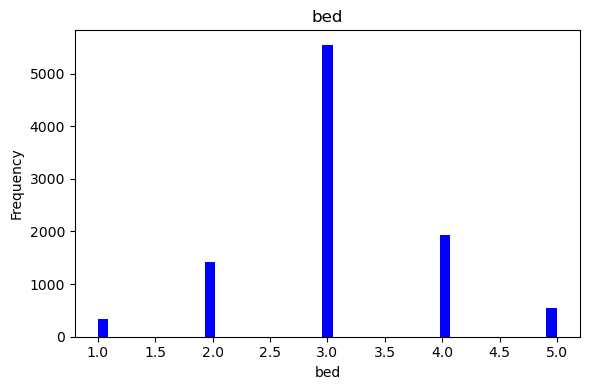

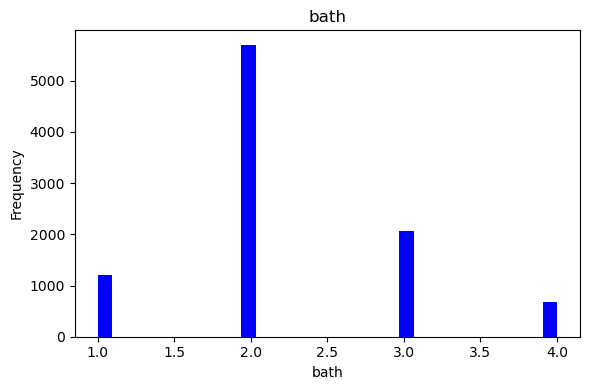

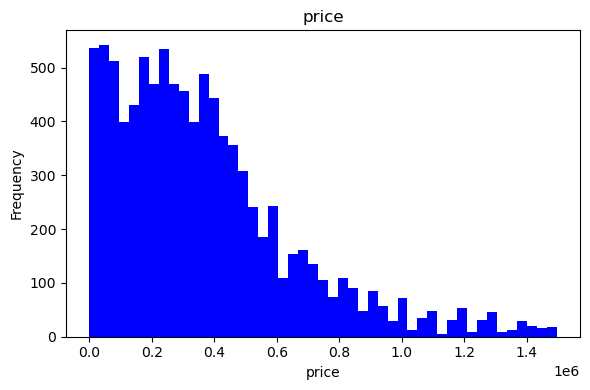

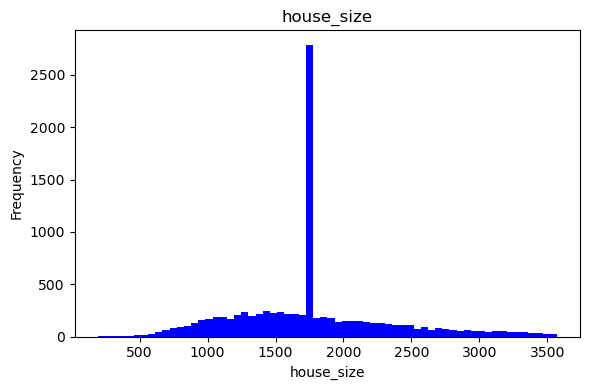

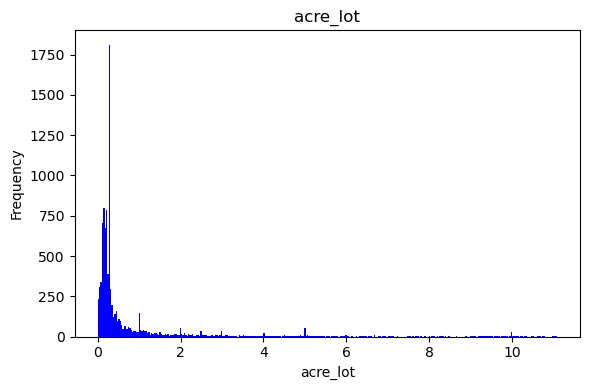

In [25]:
cols_1 = ['bed', 'bath', 'price', 'house_size', 'acre_lot']
for col in cols_1:
    plt.figure(figsize=(6,4))
    plt.title(col)

    upper_limit = df[col].quantile(0.95)
    data = df[col][df[col] <= upper_limit].dropna()

    plt.hist(data, bins='auto', color='blue')
    plt.xlabel(col)
    plt.ylabel("Frequency")



    plt.tight_layout()
    plt.show()

Visualize Categorical Data

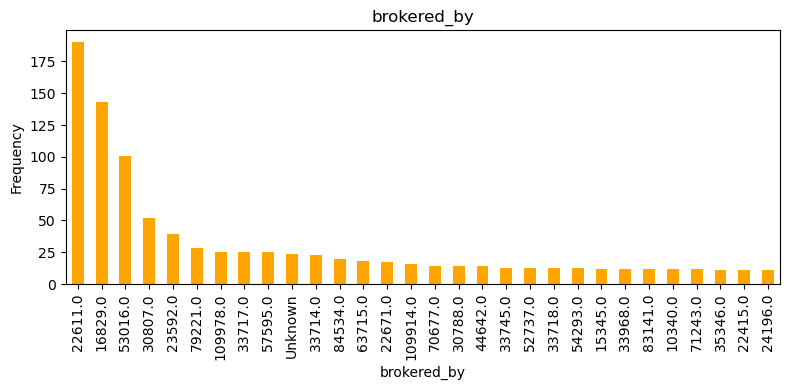

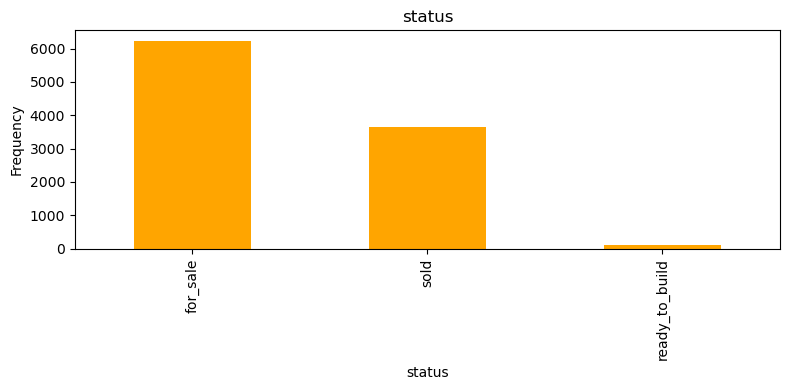

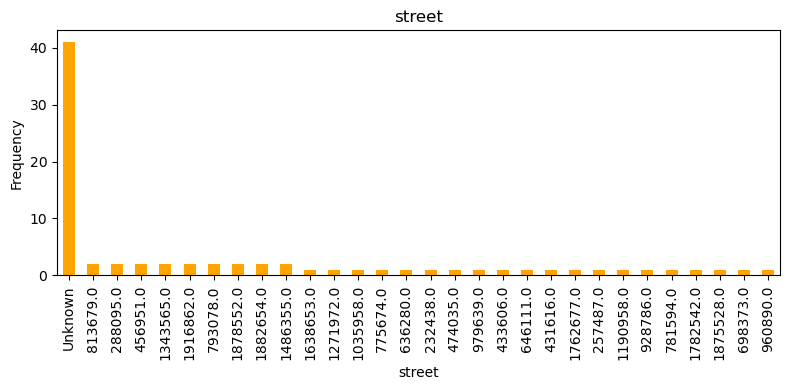

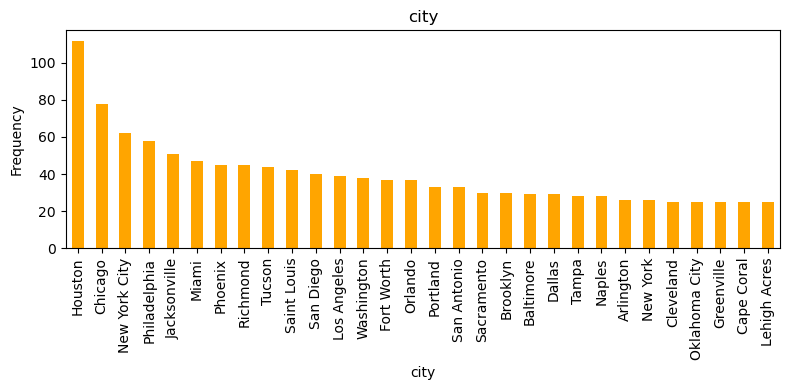

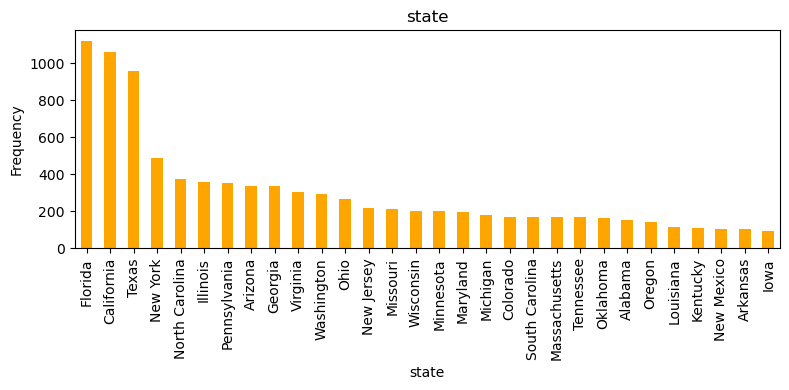

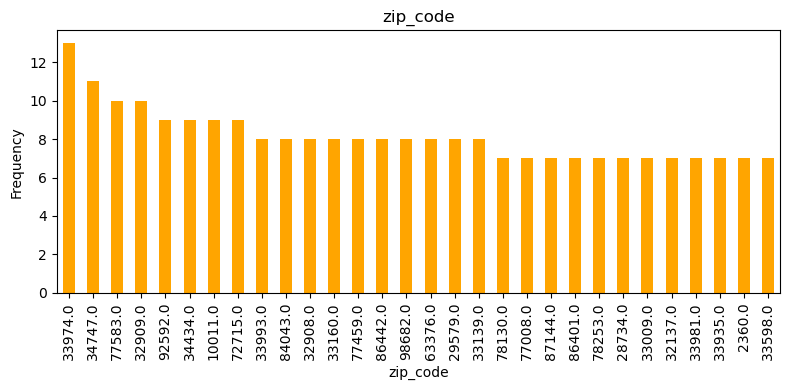

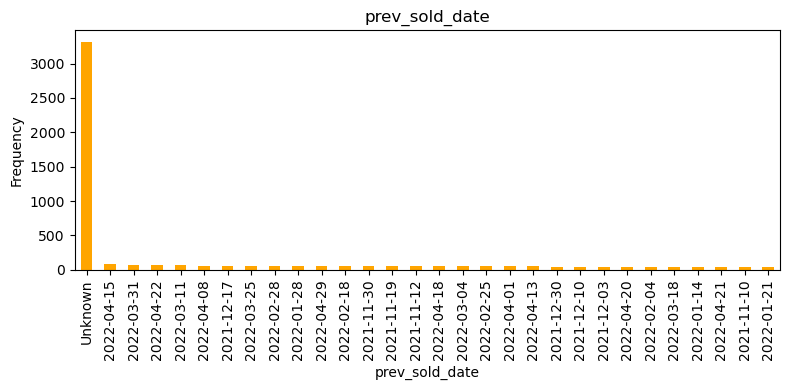

In [26]:
cols = ['brokered_by', 'status', 'street', 'city', 'state', 'zip_code', 'prev_sold_date']
top_n = 30  # show only top 10 categories

for col in cols:
    plt.figure(figsize=(8,4))
    plt.title(col)
    
    # Get top N most frequent values
    counts = df[col].value_counts().nlargest(top_n)
    
    # Plot bar chart
    counts.plot(kind='bar', color='orange')
    
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


### Split dataset

In [27]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Label Encoding

In [28]:
le = LabelEncoder()
categorical_features = ['brokered_by', 'status', 'street', 'city', 'state', 'zip_code', 'prev_sold_date']

encoded_X_train = X_train.copy()
encoded_X_test = X_test.copy()

for col in categorical_features:
    encoded_X_train[col] = le.fit_transform(X_train[col].astype(str))
    encoded_X_test[col] = X_test[col].apply(lambda x: le.transform([str(x)])[0] if str(x) in le.classes_ else -1)
    X_train[col] = X_train[col].astype('str')
    X_test[col] = X_test[col].astype('str')

### Setting Parameter

In [29]:
eta = [0.1, 0.2, 0.3, 0.4]
max_depth = [4, 5, 6, 7]
n_estimators = [100, 300, 500, 700]

params = [(e, d, n) for e in eta for d in max_depth for n in n_estimators]


XGB_res = defaultdict(dict)
CAT_res = defaultdict(dict)


### XGBoost Regression

In [30]:
for (learning_rate, depth, n_trees) in params:
    print(f"Training XGBoost Regressor with eta={learning_rate}, max_depth={depth}, n_estimators={n_trees}")
    xgb_rgs = xgb.XGBRegressor(
                                eta=learning_rate,
                                max_depth=depth,
                                n_estimators=n_trees,
                                tree_method='hist',
                                enable_categorical=True
                                )
    xgb_rgs.fit(encoded_X_train, y_train)
    y_pred_xgb = xgb_rgs.predict(encoded_X_test)
    rmse = root_mean_squared_error(y_test, y_pred_xgb)
    XGB_res[f"eta_{learning_rate}_depth_{depth}_trees_{n_trees}"] = rmse

Training XGBoost Regressor with eta=0.1, max_depth=4, n_estimators=100
Training XGBoost Regressor with eta=0.1, max_depth=4, n_estimators=300
Training XGBoost Regressor with eta=0.1, max_depth=4, n_estimators=500
Training XGBoost Regressor with eta=0.1, max_depth=4, n_estimators=700
Training XGBoost Regressor with eta=0.1, max_depth=5, n_estimators=100
Training XGBoost Regressor with eta=0.1, max_depth=5, n_estimators=300
Training XGBoost Regressor with eta=0.1, max_depth=5, n_estimators=500
Training XGBoost Regressor with eta=0.1, max_depth=5, n_estimators=700
Training XGBoost Regressor with eta=0.1, max_depth=6, n_estimators=100
Training XGBoost Regressor with eta=0.1, max_depth=6, n_estimators=300
Training XGBoost Regressor with eta=0.1, max_depth=6, n_estimators=500
Training XGBoost Regressor with eta=0.1, max_depth=6, n_estimators=700
Training XGBoost Regressor with eta=0.1, max_depth=7, n_estimators=100
Training XGBoost Regressor with eta=0.1, max_depth=7, n_estimators=300
Traini

### CATBoost Regression

In [32]:
for (learning_rate, depth, n_trees) in params:
    print(f"Training CATBoost Regressor with eta={learning_rate}, max_depth={depth}, n_estimators={n_trees}")
    cat_rgs = CatBoostRegressor(
                                learning_rate=learning_rate,
                                depth=depth,
                                iterations=n_trees,
                                verbose=0,
                                allow_writing_files=False,
                                )
    cat_rgs.fit(X_train, y_train, cat_features=categorical_features)
    y_pred_cat = cat_rgs.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred_cat)
    CAT_res[f"eta_{learning_rate}_depth_{depth}_trees_{n_trees}"] = rmse

Training CATBoost Regressor with eta=0.1, max_depth=4, n_estimators=100
Training CATBoost Regressor with eta=0.1, max_depth=4, n_estimators=300
Training CATBoost Regressor with eta=0.1, max_depth=4, n_estimators=500
Training CATBoost Regressor with eta=0.1, max_depth=4, n_estimators=700
Training CATBoost Regressor with eta=0.1, max_depth=5, n_estimators=100
Training CATBoost Regressor with eta=0.1, max_depth=5, n_estimators=300
Training CATBoost Regressor with eta=0.1, max_depth=5, n_estimators=500
Training CATBoost Regressor with eta=0.1, max_depth=5, n_estimators=700
Training CATBoost Regressor with eta=0.1, max_depth=6, n_estimators=100
Training CATBoost Regressor with eta=0.1, max_depth=6, n_estimators=300
Training CATBoost Regressor with eta=0.1, max_depth=6, n_estimators=500
Training CATBoost Regressor with eta=0.1, max_depth=6, n_estimators=700
Training CATBoost Regressor with eta=0.1, max_depth=7, n_estimators=100
Training CATBoost Regressor with eta=0.1, max_depth=7, n_estimat

### Visualize

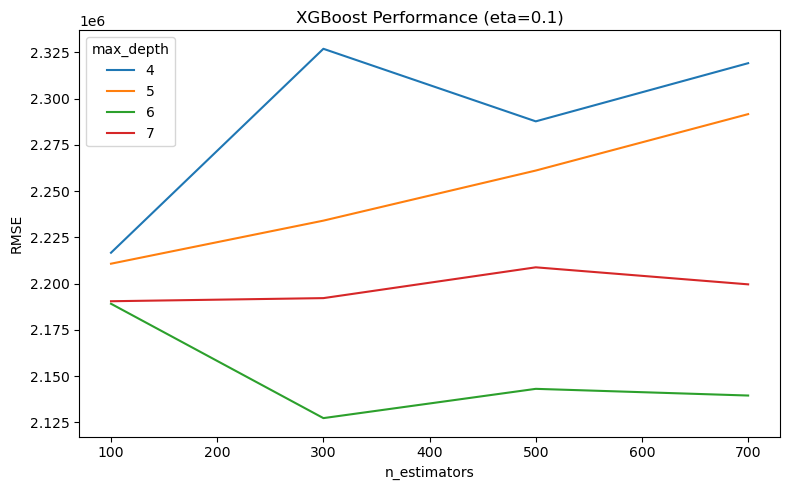

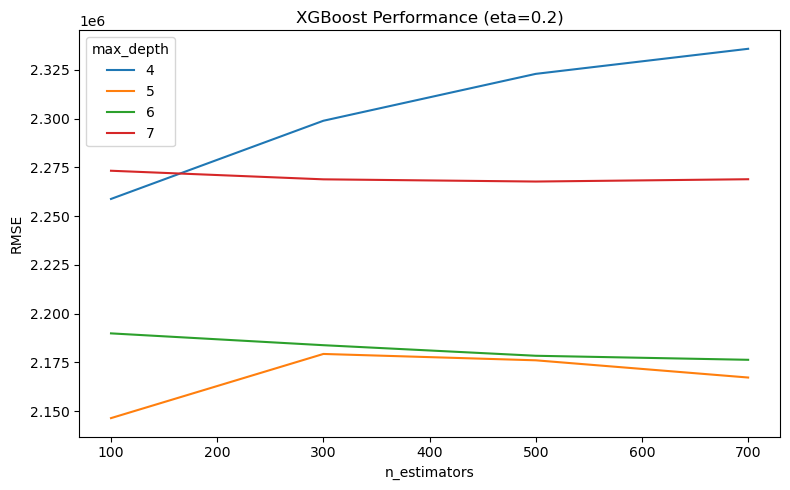

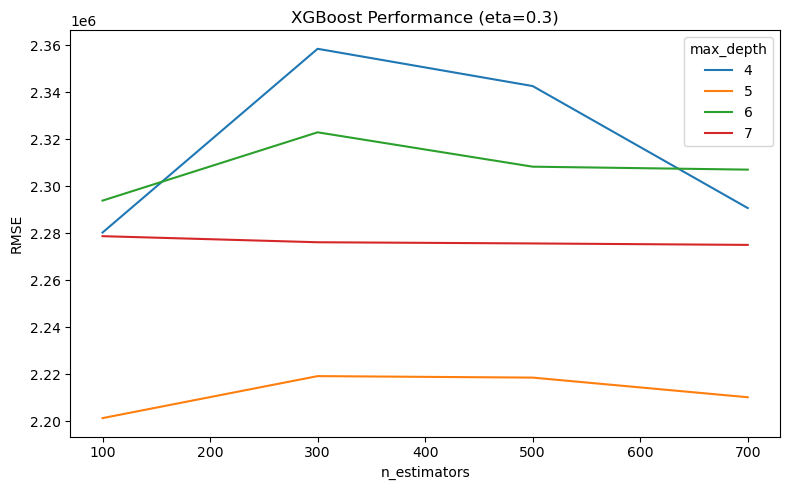

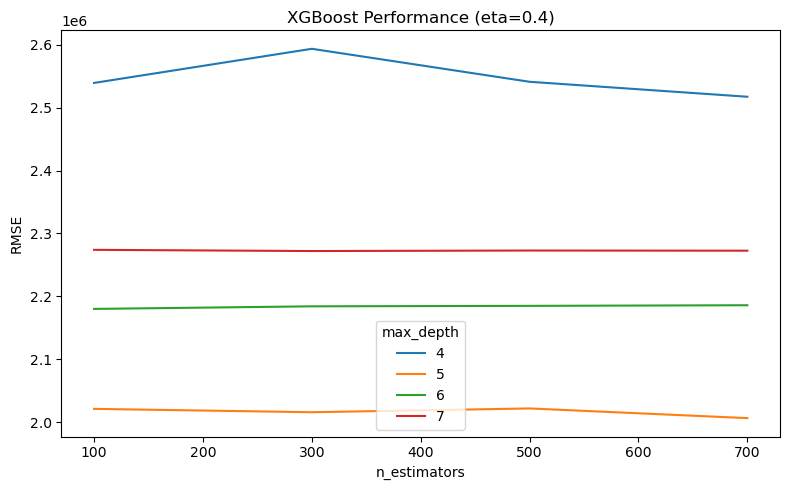

In [33]:
XGBdata = []

for key, acc in XGB_res.items():
    # Parse key
    parts = key.split('_')
    eta_val = float(parts[1])
    depth_val = int(parts[3])
    trees_val = int(parts[5])
    
    XGBdata.append([eta_val, depth_val, trees_val, acc])

df_XGB_res = pd.DataFrame(XGBdata, columns=['eta', 'max_depth', 'n_estimators', 'RMSE'])
for eta_val in df_XGB_res['eta'].unique():
    plt.figure(figsize=(8, 5))
    subset = df_XGB_res[df_XGB_res['eta'] == eta_val]
    
    sns.lineplot(
        data=subset,
        x='n_estimators',
        y='RMSE',
        hue='max_depth',     # now use max_depth for hue
        palette='tab10',
        markers=True,
    )
    
    plt.title(f'XGBoost Performance (eta={eta_val})')
    plt.xlabel('n_estimators')
    plt.ylabel('RMSE')
    plt.legend(title='max_depth')
    plt.tight_layout()
    plt.show()

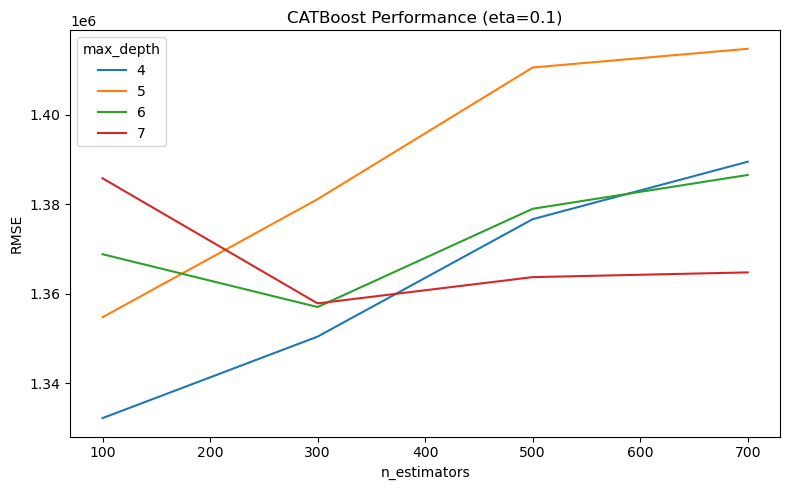

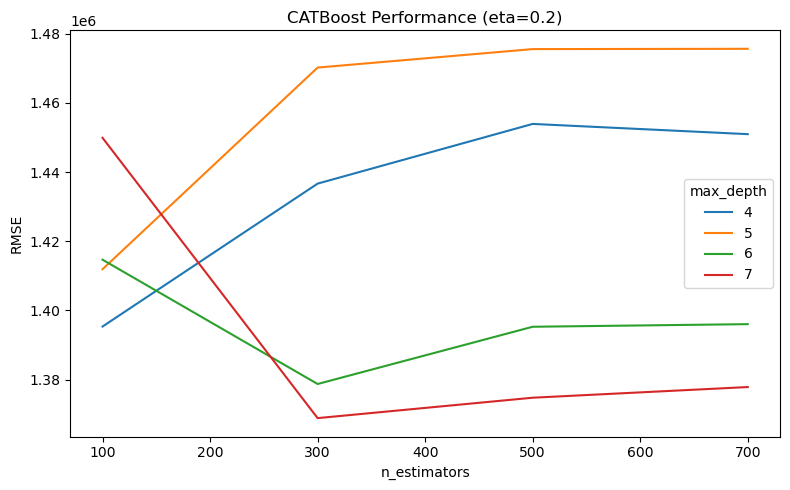

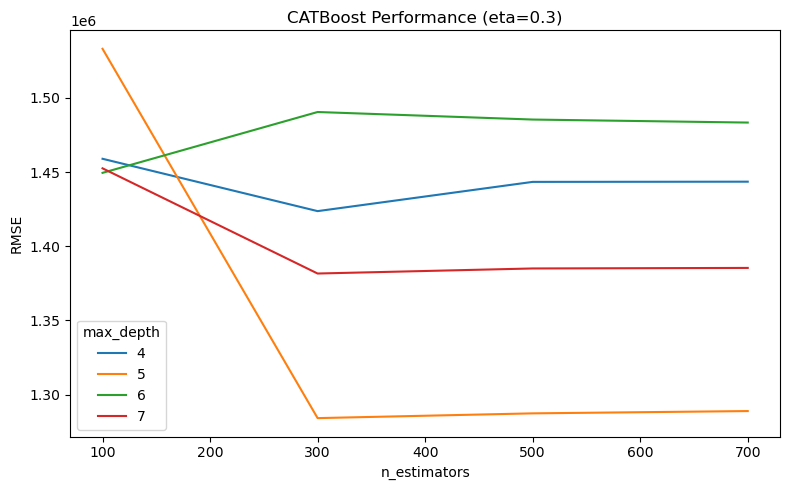

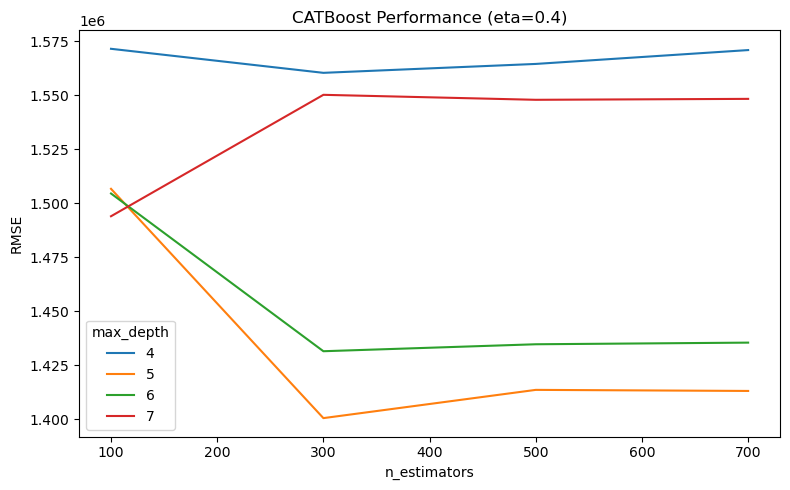

In [34]:
CATdata = []

for key, acc in CAT_res.items():
    # Parse key
    parts = key.split('_')
    eta_val = float(parts[1])
    depth_val = int(parts[3])
    trees_val = int(parts[5])
    
    CATdata.append([eta_val, depth_val, trees_val, acc])

df_cat_res = pd.DataFrame(CATdata, columns=['eta', 'max_depth', 'n_estimators', 'RMSE'])

for eta_val in df_cat_res['eta'].unique():
    plt.figure(figsize=(8, 5))
    subset = df_cat_res[df_cat_res['eta'] == eta_val]
    
    sns.lineplot(
        data=subset,
        x='n_estimators',
        y='RMSE',
        hue='max_depth',     # now use max_depth for hue
        markers=True,
        palette='tab10'
    )
    
    plt.title(f'CATBoost Performance (eta={eta_val})')
    plt.xlabel('n_estimators')
    plt.ylabel('RMSE')
    plt.legend(title='max_depth')
    plt.tight_layout()
    plt.show()

## Best Model 

### XGBoost

In [ ]:
best_xgb_params = min(XGB_res, key=XGB_res.get)
parts = best_xgb_params.split('_')
eta_val = float(parts[1])
depth_val = int(parts[3])
trees_val = int(parts[5])
best_xgb_rmse = XGB_res[best_xgb_params]

print("Best XGBoost parameters:")
print(f"eta: {eta_val}, depth: {depth_val}, tree: {trees_val} with RMSE: {best_xgb_rmse}")

Best XGBoost parameters:
eta: 0.4, depth: 5, tree: 700 with RMSE: 2006476.1203701308


### CATBoost

In [41]:
best_CAT_params = min(CAT_res, key=CAT_res.get)
parts = best_CAT_params.split('_')
eta_val = float(parts[1])
depth_val = int(parts[3])
trees_val = int(parts[5])
best_CAT_rmse = CAT_res[best_CAT_params]

print(f"Best CATBoost parameters:")
print(f"eta: {eta_val}, depth: {depth_val}, tree: {trees_val} with RMSE: {best_CAT_rmse}")

Best CATBoost parameters:
eta: 0.3, depth: 5, tree: 300 with RMSE: 1284123.6640891822
